In [ ]:
!pip install -q keras-hub

from google.colab import drive
drive.mount('/content/drive')

import os
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import keras_hub

keras.backend.clear_session()

tf.config.optimizer.set_jit(False)

print("TensorFlow version:", tf.__version__)
print("XLA disabled.")

Mounted at /content/drive
TensorFlow version: 2.20.0
XLA disabled.


In [ ]:
IMG_HEIGHT = 224
IMG_WIDTH  = 224
BACKBONE_PRESET = "dinov2_large"

OUTPUT_DIR = Path("/content/drive/MyDrive/Speciale/Models/Model_3_V3_DINO_RGB_only")
PREP_DIR = OUTPUT_DIR / "prep_files"

TEST_CSV = PREP_DIR / "test_rgb_only.csv"
VAL_CSV  = PREP_DIR / "val_rgb_only.csv"

WEIGHTS_PATH = OUTPUT_DIR / "best_model_stage2.weights.h5"

print("Output dir exists:", OUTPUT_DIR.exists())
print("Test CSV exists:", TEST_CSV.exists())
print("Weights path:", WEIGHTS_PATH)
print("Weights exist:", WEIGHTS_PATH.exists())

Output dir exists: True
Test CSV exists: True
Weights path: /content/drive/MyDrive/Speciale/Models/Model_3_V3_DINO_RGB_only/best_model_stage2.weights.h5
Weights exist: True


Loading dataset

In [ ]:
test_df = pd.read_csv(TEST_CSV)

print("Test samples:", len(test_df))
print(test_df.columns)
display(test_df.head())

Test samples: 507
Index(['dish_id', 'total_carb', 'split', 'source_cafe', 'rgb_path',
       'rgb_exists', 'rgb_size'],
      dtype='object')


,dish_id,total_carb,split,source_cafe,rgb_path,rgb_exists,rgb_size
0,dish_1556575327,10.618,test,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,548259
1,dish_1557861216,0.000,test,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,353804
2,dish_1557862345,0.000,test,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,407501
3,dish_1557862696,3.850,test,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,391780
4,dish_1557862738,0.000,test,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,412017


Loading images

Sample image shape: (224, 224, 3)
Sample image min/max: 0.0 222.105


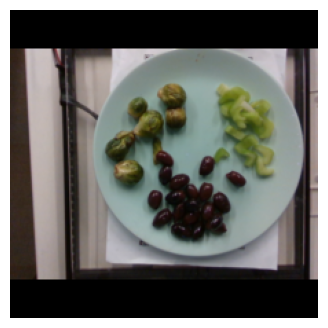

In [ ]:
def load_rgb_image(rgb_path):
    image = tf.io.read_file(str(rgb_path))
    image = tf.image.decode_png(image, channels=3)

    image = tf.image.resize_with_pad(
        image,
        target_height=IMG_HEIGHT,
        target_width=IMG_WIDTH,
        method=tf.image.ResizeMethod.BILINEAR,
        antialias=True
    )

    image = tf.cast(image, tf.float32)
    return image


def display_image(img):
    img = img.numpy() if isinstance(img, tf.Tensor) else img
    img = img.astype("float32")

    if img.max() > 1.5:
        img = img / 255.0

    return np.clip(img, 0, 1)


sample_path = test_df.iloc[0]["rgb_path"]
sample_img = load_rgb_image(sample_path)

print("Sample image shape:", sample_img.shape)
print("Sample image min/max:", tf.reduce_min(sample_img).numpy(), tf.reduce_max(sample_img).numpy())

plt.figure(figsize=(4, 4))
plt.imshow(display_image(sample_img))
plt.axis("off")
plt.show()

Rebuilding Model 3 V3

In [ ]:
image_converter = keras_hub.layers.ImageConverter.from_preset(
    BACKBONE_PRESET,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
)

backbone = keras_hub.models.Backbone.from_preset(
    BACKBONE_PRESET,
    image_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
)

backbone.trainable = False


def extract_backbone_tensor(x):
    if isinstance(x, dict):
        preferred_keys = [
            "sequence_output",
            "pooled_output",
            "encoder_output",
            "token_embeddings",
            "hidden_states"
        ]
        for key in preferred_keys:
            if key in x:
                return x[key]
        return list(x.values())[0]

    return x


rgb_input = keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3), name="rgb_input")

x = image_converter(rgb_input)
x = backbone(x)
token_tensor = extract_backbone_tensor(x)

x = token_tensor

if len(x.shape) == 3:
    x = layers.LayerNormalization()(x)
    x = layers.GlobalAveragePooling1D(name="token_pool")(x)
else:
    x = layers.LayerNormalization()(x)
    x = layers.Flatten()(x)

x = layers.Dropout(0.3)(x)
x = layers.Dense(256, activation="relu", name="dense_256")(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(64, activation="relu", name="dense_64")(x)
output = layers.Dense(1, activation="linear", name="carb_output")(x)

model = keras.Model(
    inputs={"rgb_input": rgb_input},
    outputs=output,
    name="rgb_only_dino_vit_regressor"
)

# Important: cam_model uses the SAME layers and SAME graph.
# It outputs both the DINOv2 tokens and final carb prediction.
cam_model = keras.Model(
    inputs={"rgb_input": rgb_input},
    outputs=[token_tensor, output],
    name="cam_model"
)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="mse",
    metrics=[
        keras.metrics.MeanAbsoluteError(name="mae"),
        keras.metrics.MeanSquaredError(name="mse")
    ],
    jit_compile=False
)

model.load_weights(str(WEIGHTS_PATH))

print("Model rebuilt.")
print("Weights loaded successfully.")

100%|██████████| 782/782 [00:00<00:00, 1.16MB/s]


100%|██████████| 977/977 [00:00<00:00, 2.55MB/s]


100%|██████████| 1.14G/1.14G [00:25<00:00, 47.7MB/s]


Model rebuilt.
Weights loaded successfully.


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 886 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
row = test_df.iloc[0]
img = load_rgb_image(row["rgb_path"])
img_tensor = tf.expand_dims(img, axis=0)

pred = model({"rgb_input": img_tensor}, training=False)

print("Prediction tensor:", pred)
print("Predicted carbs:", float(pred.numpy()[0, 0]))
print("True carbs:", float(row["total_carb"]))

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'images': 'images'}
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


Prediction tensor: tf.Tensor([[12.507243]], shape=(1, 1), dtype=float32)
Predicted carbs: 12.507243156433105
True carbs: 10.618


In [ ]:
def infer_patch_grid(num_tokens):
    """
    DINOv2 ViT outputs patch tokens plus possible special tokens.
    This tries to infer whether there are 0, 1, or 2 special tokens.
    """
    for special_tokens in [2, 1, 0]:
        patch_count = num_tokens - special_tokens
        grid_size = int(math.sqrt(patch_count))

        if grid_size * grid_size == patch_count:
            return special_tokens, grid_size

    raise ValueError(f"Could not infer patch grid from {num_tokens} tokens.")


def get_model_prediction(img_tensor):
    """
    Direct model call.
    Do not use model.predict(), since it can trigger XLA ResizeBicubic errors.
    """
    pred = model({"rgb_input": img_tensor}, training=False)
    return float(pred.numpy()[0, 0])


def make_clean_heatmap(img_tensor):
    """
    Grad-CAM-style heatmap for DINOv2 patch tokens.
    """
    img_tensor = tf.cast(img_tensor, tf.float32)

    with tf.GradientTape() as tape:
        token_output, prediction = cam_model(
            {"rgb_input": img_tensor},
            training=False
        )

        score = prediction[:, 0]

    grads = tape.gradient(score, token_output)

    if grads is None:
        raise ValueError(
            "Gradients are None. token_output is not connected to prediction."
        )

    tokens = token_output[0]
    grads = grads[0]

    num_tokens = int(tokens.shape[0])
    num_special, grid_size = infer_patch_grid(num_tokens)

    patch_tokens = tokens[num_special:]
    patch_grads = grads[num_special:]

    # Grad-CAM weighting
    weights = tf.reduce_mean(patch_grads, axis=0)

    cam = tf.reduce_sum(patch_tokens * weights, axis=-1)
    cam = tf.nn.relu(cam)

    cam = cam.numpy().reshape(grid_size, grid_size)

    # Normalize patch map
    cam = cam - cam.min()
    if cam.max() > 0:
        cam = cam / cam.max()

    # Upsample to image resolution
    cam = tf.image.resize(
        cam[..., None],
        size=(IMG_HEIGHT, IMG_WIDTH),
        method="bicubic"
    ).numpy().squeeze()

    # Smooth to make it visually cleaner
    cam_tf = tf.convert_to_tensor(cam[None, ..., None], dtype=tf.float32)
    cam_tf = tf.nn.avg_pool2d(
        cam_tf,
        ksize=9,
        strides=1,
        padding="SAME"
    )
    cam = cam_tf[0, ..., 0].numpy()

    # Normalize again after smoothing
    cam = cam - cam.min()
    if cam.max() > 0:
        cam = cam / cam.max()

    return cam


def overlay_heatmap(img_disp, heatmap, alpha=0.45, cmap_name="jet"):
    cmap = plt.get_cmap(cmap_name)
    heatmap_rgb = cmap(heatmap)[..., :3]

    overlay = (1 - alpha) * img_disp + alpha * heatmap_rgb
    overlay = np.clip(overlay, 0, 1)

    return overlay

Visualizing one dish

In [ ]:
def visualize_one_dish(df, row_idx=0, dish_id=None):
    if dish_id is not None:
        matches = df[df["dish_id"].astype(str) == str(dish_id)]

        if len(matches) == 0:
            raise ValueError(f"Dish ID not found: {dish_id}")

        row = matches.iloc[0]
    else:
        row = df.iloc[row_idx]

    rgb_path = row["rgb_path"]
    true_carb = float(row["total_carb"])
    dish = row["dish_id"]

    img = load_rgb_image(rgb_path)
    img_tensor = tf.expand_dims(img, axis=0)

    pred = get_model_prediction(img_tensor)

    img_disp = display_image(img)
    heatmap = make_clean_heatmap(img_tensor)
    overlay = overlay_heatmap(img_disp, heatmap, alpha=0.45)

    fig, axes = plt.subplots(1, 3, figsize=(13, 4))

    axes[0].imshow(img_disp)
    axes[0].set_title("Image")
    axes[0].axis("off")

    axes[1].imshow(heatmap, cmap="jet", vmin=0, vmax=1)
    axes[1].set_title("Carb heatmap")
    axes[1].axis("off")

    axes[2].imshow(overlay)
    axes[2].set_title("Overlay")
    axes[2].axis("off")

    plt.suptitle(str(dish), fontsize=13)
    plt.tight_layout()
    plt.show()

    print("Dish:", dish)
    print("RGB path:", rgb_path)
    print("True carbs:", true_carb)
    print("Predicted carbs:", pred)
    print("Absolute error:", abs(pred - true_carb))

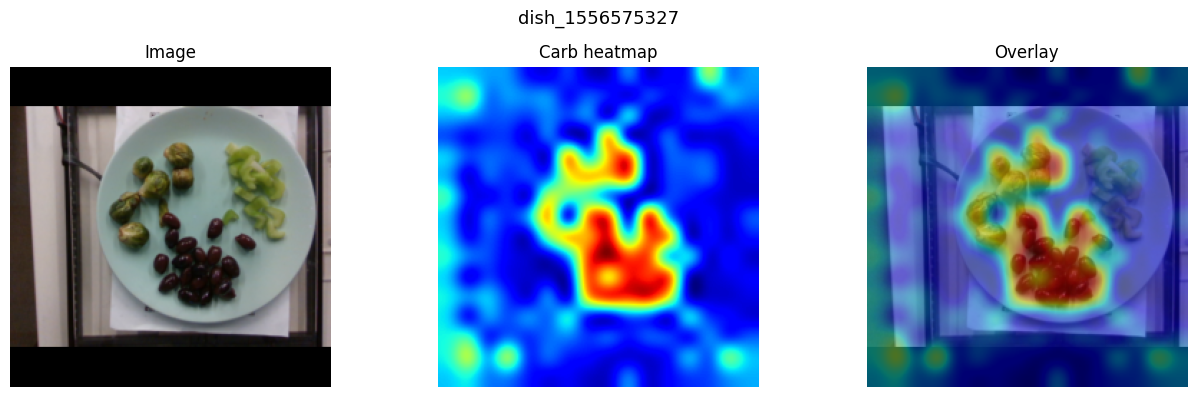

Dish: dish_1556575327
RGB path: /content/drive/MyDrive/Speciale/dataset/nutrition5k_compactV3/dish_1556575327/overhead/rgb.png
True carbs: 10.618
Predicted carbs: 12.507243156433105
Absolute error: 1.8892431564331051


In [ ]:
visualize_one_dish(test_df, row_idx=0)

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'images': 'images'}
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


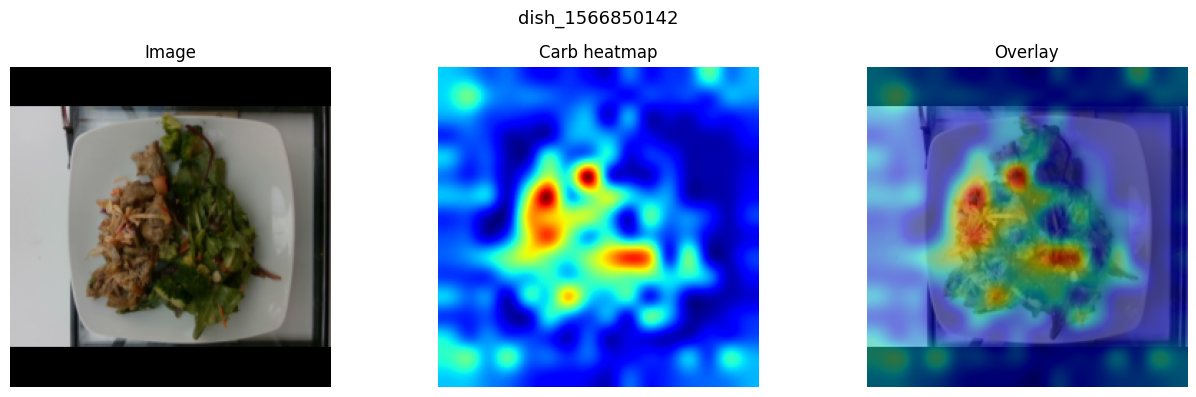

Dish: dish_1566850142
RGB path: /content/drive/MyDrive/Speciale/dataset/nutrition5k_compactV3/dish_1566850142/overhead/rgb.png
True carbs: 9.052546
Predicted carbs: 15.729094505310059
Absolute error: 6.676548505310059


In [ ]:
visualize_one_dish(test_df, dish_id="dish_1566850142")

dish_1562790855

Visualizing multiple dishes

In [ ]:
def visualize_rdinet_style(
    df,
    n_samples=4,
    dish_ids=None,
    random_state=42,
    save_path=None
):
    if dish_ids is not None:
        selected_df = df[df["dish_id"].astype(str).isin([str(x) for x in dish_ids])].copy()

        if len(selected_df) == 0:
            raise ValueError("None of the provided dish_ids were found.")

    else:
        selected_df = df.sample(n=n_samples, random_state=random_state).copy()

    selected_df = selected_df.reset_index(drop=True)
    n = len(selected_df)

    fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))

    if n == 1:
        axes = np.expand_dims(axes, axis=0)

    column_titles = ["Image", "Carb heatmap", "Overlay"]

    for j, title in enumerate(column_titles):
        axes[0, j].set_title(title, fontsize=14)

    for i, row in selected_df.iterrows():
        rgb_path = row["rgb_path"]
        true_carb = float(row["total_carb"])
        dish = row["dish_id"]

        img = load_rgb_image(rgb_path)
        img_tensor = tf.expand_dims(img, axis=0)

        pred = get_model_prediction(img_tensor)

        img_disp = display_image(img)
        heatmap = make_clean_heatmap(img_tensor)
        overlay = overlay_heatmap(img_disp, heatmap, alpha=0.45)

        axes[i, 0].imshow(img_disp)
        axes[i, 0].set_ylabel(
            str(dish),
            rotation=0,
            labelpad=70,
            fontsize=10,
            va="center"
        )
        axes[i, 0].axis("off")

        axes[i, 1].imshow(heatmap, cmap="jet", vmin=0, vmax=1)
        axes[i, 1].axis("off")

        axes[i, 2].imshow(overlay)
        axes[i, 2].set_xlabel(
            f"True: {true_carb:.2f}g | Pred: {pred:.2f}g | AE: {abs(pred - true_carb):.2f}g",
            fontsize=9
        )
        axes[i, 2].axis("off")

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print("Saved figure to:", save_path)

    plt.show()

Saved figure to: /content/drive/MyDrive/Speciale/Models/Model_3_V3_DINO_RGB_only/model_3_v3_clean_heatmaps.png


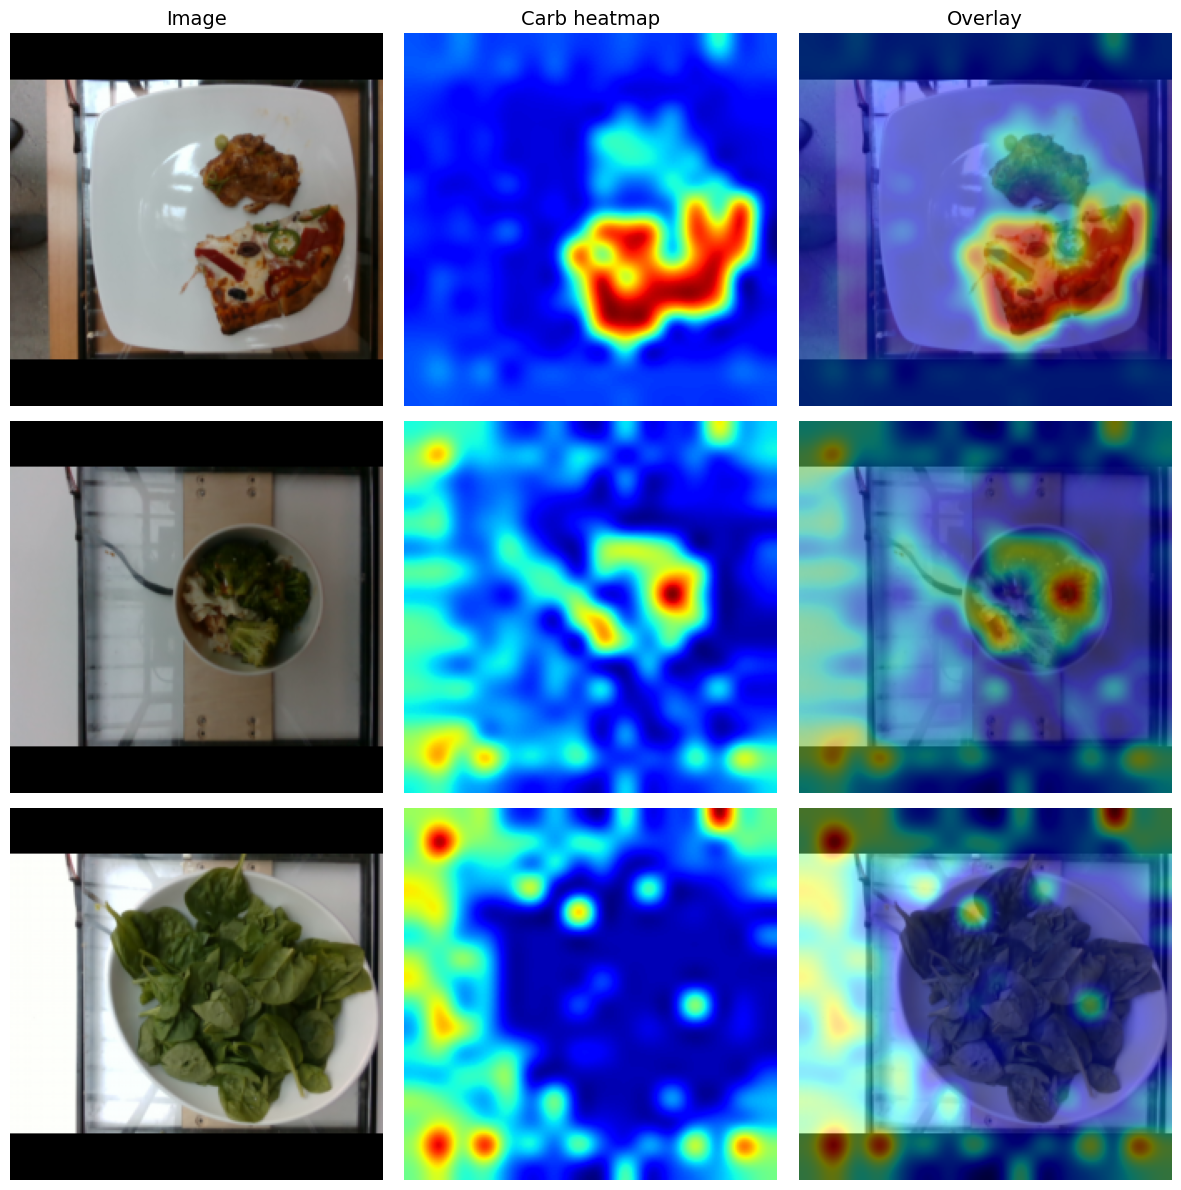

In [ ]:
visualize_rdinet_style(
    test_df,
    n_samples=3,
    random_state=152,
    save_path=str(OUTPUT_DIR / "model_3_v3_clean_heatmaps.png")
)

In [ ]:
# Example with manually selected dish IDs.
# Replace these with dish IDs from your test_df.

selected_dishes = [
    test_df.iloc[0]["dish_id"],
    test_df.iloc[1]["dish_id"],
    test_df.iloc[2]["dish_id"],
    test_df.iloc[3]["dish_id"],
]

visualize_rdinet_style(
    test_df,
    dish_ids=selected_dishes,
    save_path=str(OUTPUT_DIR / "model_3_v3_selected_clean_heatmaps.png")
)

In [ ]:
# ============================================================
# CLEAN MULTI-DISH HEATMAP FIGURE
# Same style as single-image visualization
# Shows dish ID + true carb + predicted carb + AE
# ============================================================

def visualize_three_dishes_clean(
    df,
    dish_ids,
    save_path=None,
    figure_title=None,
    alpha=0.45
):
    """
    Clean main-text figure for manually selected dishes.

    Columns:
    - Image
    - Carb heatmap
    - Overlay with true/predicted carbohydrate estimate

    Parameters
    ----------
    df : dataframe
        Must contain dish_id, rgb_path, total_carb.
    dish_ids : list
        List of manually selected dish IDs.
    save_path : str or None
        Optional path for saving the figure.
    figure_title : str or None
        Optional figure title.
    alpha : float
        Overlay transparency.
    """

    dish_ids_str = [str(x) for x in dish_ids]

    selected_rows = []

    for dish in dish_ids_str:
        match = df[df["dish_id"].astype(str) == dish]

        if len(match) == 0:
            print(f"WARNING: Dish not found: {dish}")
            continue

        selected_rows.append(match.iloc[0])

    if len(selected_rows) == 0:
        raise ValueError("None of the provided dish IDs were found.")

    n = len(selected_rows)

    fig, axes = plt.subplots(
        n,
        3,
        figsize=(13, 4.7 * n)
    )

    if n == 1:
        axes = np.expand_dims(axes, axis=0)

    # Column headers only on first row
    axes[0, 0].set_title("Image", fontsize=14, pad=12)
    axes[0, 1].set_title("Carb heatmap", fontsize=14, pad=12)
    axes[0, 2].set_title("Overlay", fontsize=14, pad=12)

    for i, row in enumerate(selected_rows):
        rgb_path = row["rgb_path"]
        true_carb = float(row["total_carb"])
        dish = str(row["dish_id"])

        img = load_rgb_image(rgb_path)
        img_tensor = tf.expand_dims(img, axis=0)

        pred = get_model_prediction(img_tensor)
        abs_error = abs(pred - true_carb)

        img_disp = display_image(img)
        heatmap = make_clean_heatmap(img_tensor)
        overlay = overlay_heatmap(img_disp, heatmap, alpha=alpha)

        # -------------------------
        # Image
        # -------------------------
        axes[i, 0].imshow(img_disp)
        axes[i, 0].axis("off")

        # Put dish ID below image column title area
        axes[i, 0].text(
            0.5,
            -0.08,
            dish,
            transform=axes[i, 0].transAxes,
            ha="center",
            va="top",
            fontsize=10
        )

        # -------------------------
        # Heatmap
        # -------------------------
        axes[i, 1].imshow(heatmap, cmap="jet", vmin=0, vmax=1)
        axes[i, 1].axis("off")

        # -------------------------
        # Overlay
        # -------------------------
        axes[i, 2].imshow(overlay)
        axes[i, 2].axis("off")

        # Put prediction text ABOVE the overlay image
        # This is the key fix compared to the previous version
        axes[i, 2].text(
            0.5,
            -0.08,
            f"True: {true_carb:.2f}g | Pred: {pred:.2f}g | AE: {abs_error:.2f}g",
            transform=axes[i, 2].transAxes,
            ha="center",
            va="top",
            fontsize=10
        )

    if figure_title is not None:
        fig.suptitle(figure_title, fontsize=16, y=0.995)

    plt.subplots_adjust(
        top=0.93 if figure_title is not None else 0.96,
        bottom=0.04,
        hspace=0.32,
        wspace=0.08
    )

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print("Saved figure to:", save_path)

    plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'images': 'images'}
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


Saved figure to: /content/drive/MyDrive/Speciale/Models/Model_3_V3_DINO_RGB_only/model_3_v3_main_text_three_heatmaps.png


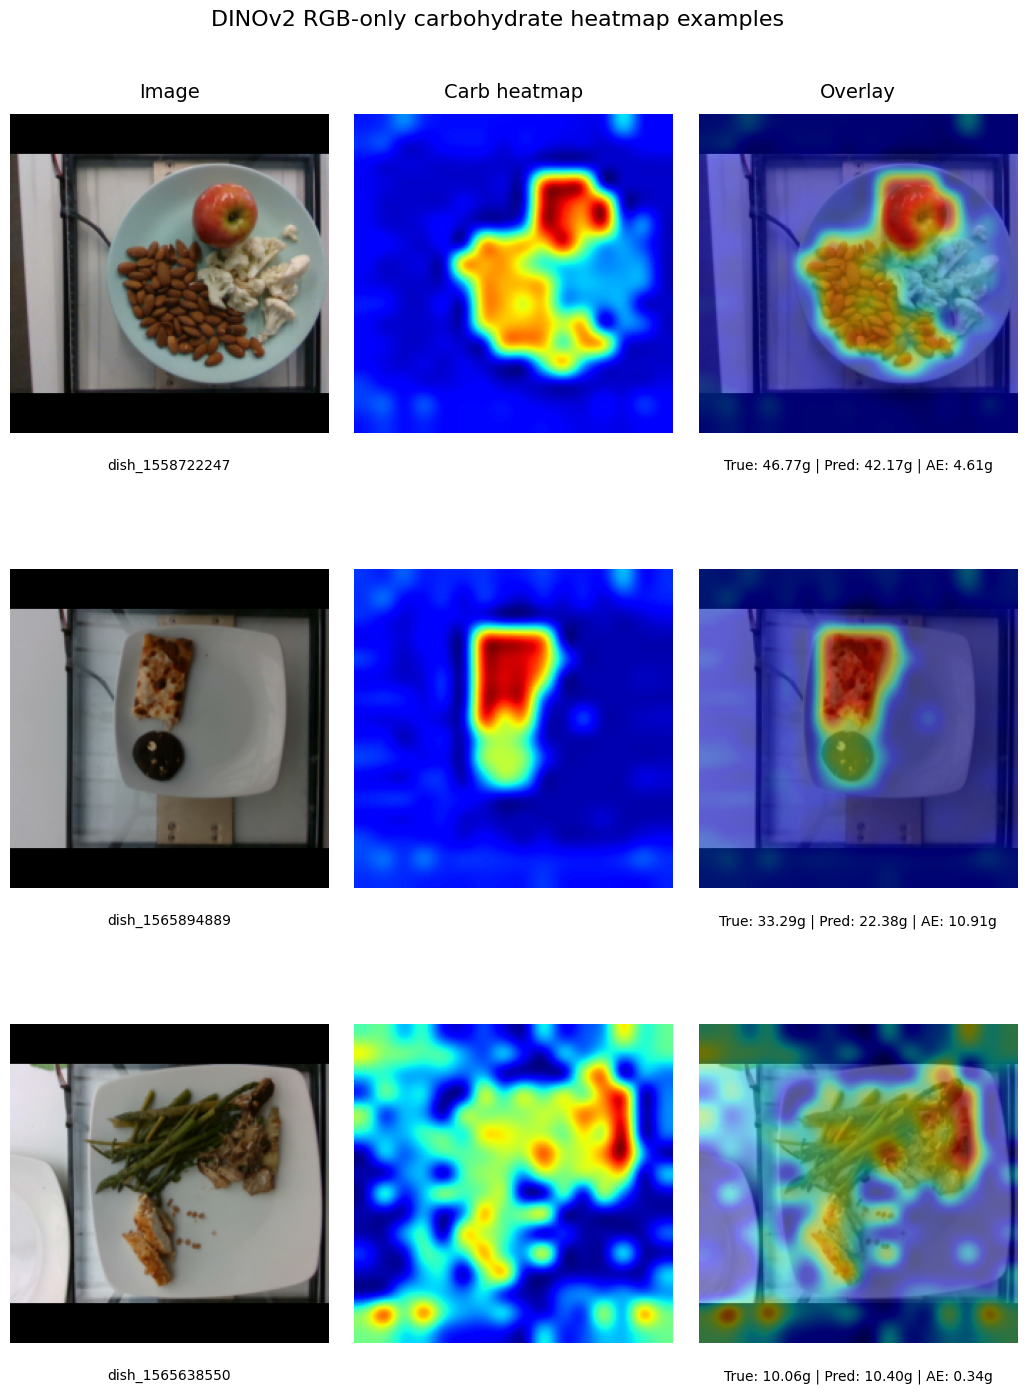

In [ ]:
selected_dishes_main_text = [
    "dish_1558722247",
    "dish_1565894889",
    "dish_1565638550",
]

visualize_three_dishes_clean(
    test_df,
    dish_ids=selected_dishes_main_text,
    save_path=str(OUTPUT_DIR / "model_3_v3_main_text_three_heatmaps.png"),
    figure_title="DINOv2 RGB-only carbohydrate heatmap examples",
    alpha=0.45
)